# Deep Learning Baseline for RUL Prediction

This notebook builds initial deep learning baselines for Remaining Useful Life prediction using time-windowed sensor data from C-MAPSS FD001. The objective is to compare sequence-based models (1D-CNN and GRU) against the best classical baseline from Step 4.

## 0. Colab Setup

Run this cell first. It mounts Google Drive, installs dependencies, and sets up paths.
Upload the following files to `MyDrive/Dissertation/Project/dissertation-rul-xai/data/processed/` before running:
- `train_b_fd001.csv`, `val_b_fd001.csv`, `test_b_fd001.csv`
- `classical_baseline_results_fd001.csv` (to `MyDrive/Dissertation/Project/dissertation-rul-xai/reports/metrics/`)

In [1]:
import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install any missing packages (TF and sklearn are pre-installed on Colab)
# Uncomment if versions differ
# !pip install -q tensorflow scikit-learn pandas matplotlib

# Verify GPU
import tensorflow as tf
print(f'TensorFlow: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Devices: {tf.config.list_physical_devices()}')

# Base project directory on Drive
DRIVE_BASE = '/content/drive/MyDrive/Dissertation/Project/dissertation-rul-xai'

DATA_DIR     = f'{DRIVE_BASE}/data/processed'
METRICS_DIR  = f'{DRIVE_BASE}/reports/metrics'
FIG_DIR      = f'{DRIVE_BASE}/reports/figures'
PRED_DIR     = f'{DRIVE_BASE}/reports/predictions'
MODEL_DIR    = f'{DRIVE_BASE}/models/deep_learning'

for d in [METRICS_DIR, FIG_DIR, PRED_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print('Paths set up.')

Mounted at /content/drive
TensorFlow: 2.20.0
GPU available: True
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Paths set up.


## 1. Imports and Setup

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


## 2. Load Processed Feature Set B Data

In [3]:
train_df = pd.read_csv(f'{DATA_DIR}/train_b_fd001.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_b_fd001.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_b_fd001.csv')

print('Train:', train_df.shape)
print('Validation:', val_df.shape)
print('Test:', test_df.shape)

Train: (16340, 18)
Validation: (4291, 18)
Test: (13096, 18)


In [4]:
target_col    = 'RUL_capped'
metadata_cols = ['unit_number', 'time_in_cycles', 'RUL', 'RUL_capped']

feature_cols = [col for col in train_df.columns if col not in metadata_cols]

print(f'Number of input features: {len(feature_cols)}')
print(feature_cols)

Number of input features: 14
['sensor_measurement_11', 'sensor_measurement_4', 'sensor_measurement_12', 'sensor_measurement_7', 'sensor_measurement_15', 'sensor_measurement_21', 'sensor_measurement_20', 'sensor_measurement_2', 'sensor_measurement_17', 'sensor_measurement_3', 'sensor_measurement_8', 'sensor_measurement_13', 'sensor_measurement_9', 'sensor_measurement_14']


In [5]:
for col in metadata_cols:
    assert col not in feature_cols, f'Metadata column found in features: {col}'
assert target_col in train_df.columns
print('All safety checks passed.')

All safety checks passed.


## 3. Create Time-Windowed Sequence Dataset

Each training sample consists of sensor values over the previous N cycles. The target is the capped RUL at the final cycle of that window. A window size of 30 cycles is used as the initial setting. Units shorter than the window size are skipped.

In [6]:
WINDOW_SIZE = 30

def create_windows(df, feature_cols, target_col, window_size=30, stride=1):
    X, y, meta = [], [], []

    for unit, unit_df in df.groupby('unit_number'):
        unit_df = unit_df.sort_values('time_in_cycles').reset_index(drop=True)

        feature_values = unit_df[feature_cols].values.astype(np.float32)
        target_values  = unit_df[target_col].values.astype(np.float32)
        cycles         = unit_df['time_in_cycles'].values
        raw_rul        = unit_df['RUL'].values

        if len(unit_df) < window_size:
            continue

        for i in range(window_size, len(unit_df) + 1, stride):
            X.append(feature_values[i - window_size:i])
            y.append(target_values[i - 1])
            meta.append({
                'unit_number':  unit,
                'time_in_cycles': cycles[i - 1],
                'RUL':          raw_rul[i - 1],
                'RUL_capped':   target_values[i - 1]
            })

    return np.array(X), np.array(y), pd.DataFrame(meta)

In [7]:
X_train, y_train, meta_train = create_windows(train_df, feature_cols, target_col, WINDOW_SIZE)
X_val,   y_val,   meta_val   = create_windows(val_df,   feature_cols, target_col, WINDOW_SIZE)

print(f'X_train: {X_train.shape}  (samples, timesteps, features)')
print(f'y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'y_val:   {y_val.shape}')

X_train: (14020, 30, 14)  (samples, timesteps, features)
y_train: (14020,)
X_val:   (3711, 30, 14)
y_val:   (3711,)


## 4. Windowed Dataset Summary

In [8]:
print(f'Training windows:   {len(X_train)}')
print(f'Validation windows: {len(X_val)}')
print(f'Window size:        {WINDOW_SIZE} cycles')
print(f'Features per timestep: {X_train.shape[2]}')
print(f'\nTarget (y_train) stats:')
print(f'  min={y_train.min():.1f}, max={y_train.max():.1f}, mean={y_train.mean():.1f}, std={y_train.std():.1f}')
print(f'\nUnits in train: {meta_train["unit_number"].nunique()}')
print(f'Units in val:   {meta_val["unit_number"].nunique()}')

Training windows:   14020
Validation windows: 3711
Window size:        30 cycles
Features per timestep: 14

Target (y_train) stats:
  min=0.0, max=125.0, mean=80.1, std=41.8

Units in train: 80
Units in val:   20


## 5. Model Architecture: 1D-CNN

A simple 1D convolutional model that processes the time-windowed sensor inputs. Two convolutional layers extract local temporal patterns, followed by global pooling and dense layers for regression.

In [9]:
def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(50, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

cnn_model = build_cnn_model((WINDOW_SIZE, len(feature_cols)))
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,389 (110.89 KB)

 Trainable params: 28,389 (110.89 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Architecture: GRU

A GRU-based recurrent model that processes the sensor sequence. Two GRU layers capture temporal dependencies across the window, followed by dense layers for regression.

In [10]:
def build_gru_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(64, return_sequences=True),
        layers.GRU(32),
        layers.Dense(50, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

gru_model = build_gru_model((WINDOW_SIZE, len(feature_cols)))
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         1,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,469 (103.39 KB)

 Trainable params: 26,469 (103.39 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Training Configuration

In [11]:
EPOCHS     = 30
BATCH_SIZE = 256
PATIENCE   = 10

def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

## 8. Train 1D-CNN

In [12]:
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('CNN1D'),
    verbose=1
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 4727.3726 - mae: 56.8462 - val_loss: 1659.8538 - val_mae: 33.2373 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1544.1296 - mae: 31.8673 - val_loss: 1108.9286 - val_mae: 27.2547 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1082.2604 - mae: 26.4513 - val_loss: 721.3451 - val_mae: 22.4417 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 678.7280 - mae: 20.8264 - val_loss: 481.6890 - val_mae: 17.6657 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 526.6777 - mae: 18.0898 - val_loss: 469.2800 - val_mae: 16.9972 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 485.9327 - mae: 17.2409 - val_loss: 469.1258 - val_mae: 16.9866 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 454.5250 - mae: 16.5204 - val_loss: 457.8139 - val_mae: 16.9

## 9. Train GRU

In [13]:
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks('GRU'),
    verbose=1
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 7668.0640 - mae: 76.9858 - val_loss: 7303.5181 - val_mae: 74.8535 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6091.3940 - mae: 67.1489 - val_loss: 5469.9243 - val_mae: 63.5958 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4264.8853 - mae: 54.7387 - val_loss: 3465.6746 - val_mae: 49.0283 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2542.4851 - mae: 40.8806 - val_loss: 1855.3225 - val_mae: 35.4188 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1296.6038 - mae: 29.0635 - val_loss: 908.9596 - val_mae: 25.4383 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 730.6771 - mae: 21.8767 - val_loss: 545.0502 - val_mae: 19.9409 - learning_rate: 0.0010
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 499.1466 - mae: 17.7102 - val_loss: 366.3998 - val

## 10. Training Curves

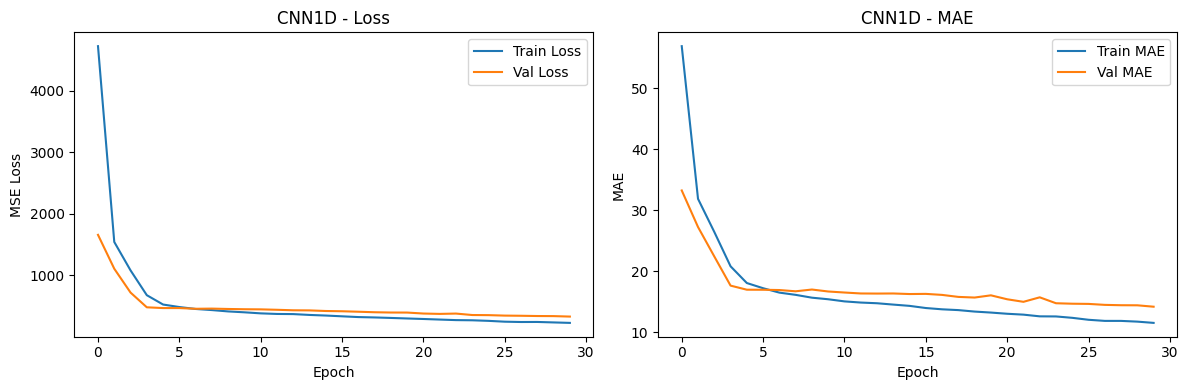

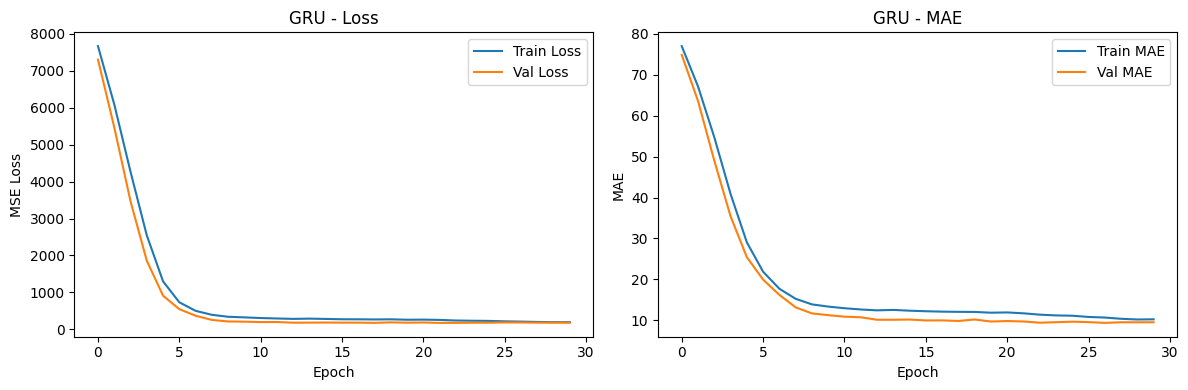

In [14]:
def plot_training_curve(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()

    axes[1].plot(history.history['mae'],     label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Val MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title(f'{model_name} - MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/training_curve_{model_name}_fd001.png', dpi=150)
    plt.show()

plot_training_curve(cnn_history, 'CNN1D')
plot_training_curve(gru_history, 'GRU')

## 11. Evaluation

In [15]:
def evaluate_model(model, X, y, model_name, feature_set='B', window_size=30):
    y_pred = model.predict(X, verbose=0).flatten()
    y_pred = np.clip(y_pred, 0, 125)

    rmse = root_mean_squared_error(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)

    return {
        'model':           model_name,
        'feature_set':     feature_set,
        'window_size':     window_size,
        'validation_rmse': round(rmse, 4),
        'validation_mae':  round(mae,  4),
        'validation_r2':   round(r2,   4),
    }, y_pred

cnn_results, cnn_preds = evaluate_model(cnn_model, X_val, y_val, 'CNN1D')
gru_results, gru_preds = evaluate_model(gru_model, X_val, y_val, 'GRU')

dl_results_df = pd.DataFrame([cnn_results, gru_results])
dl_results_df = dl_results_df.sort_values('validation_rmse').reset_index(drop=True)

dl_results_df.to_csv(f'{METRICS_DIR}/deep_learning_baseline_results_fd001.csv', index=False)
print(dl_results_df.to_string(index=False))

model feature_set  window_size  validation_rmse  validation_mae  validation_r2
  GRU           B           30          13.1605          9.7182         0.9010
CNN1D           B           30          18.1509         14.0382         0.8118


## 12. Save Models and Predictions

In [16]:
cnn_model.save(f'{MODEL_DIR}/CNN1D_B_window30_fd001.keras')
gru_model.save(f'{MODEL_DIR}/GRU_B_window30_fd001.keras')
print('Models saved.')

for model_name, preds in [('CNN1D', cnn_preds), ('GRU', gru_preds)]:
    pred_df = meta_val.copy()
    pred_df['prediction'] = preds
    pred_df['model'] = model_name
    pred_df.to_csv(f'{PRED_DIR}/val_predictions_{model_name}_B_window30_fd001.csv', index=False)

print('Predictions saved.')

Models saved.
Predictions saved.


## 13. Comparison with Classical Baseline

The best classical baseline from Step 4 was XGBoost on Feature Set C with validation RMSE 11.72 and MAE 8.32. This section compares the deep learning results against that reference.

This result is understandable at this stage because the classical baseline uses explicitly engineered degradation features (rolling statistics, delta from initial), while the deep learning baseline uses raw sensor windows and must learn those temporal patterns implicitly.

In [17]:
classical_df  = pd.read_csv(f'{METRICS_DIR}/classical_baseline_results_fd001.csv')
best_classical = classical_df.iloc[0]

comparison_rows = []
comparison_rows.append({
    'model':           best_classical['model'],
    'feature_set':     best_classical['feature_set'],
    'model_type':      'Classical',
    'validation_rmse': best_classical['validation_rmse'],
    'validation_mae':  best_classical['validation_mae'],
    'validation_r2':   best_classical['validation_r2'],
})

for _, row in dl_results_df.iterrows():
    comparison_rows.append({
        'model':           row['model'],
        'feature_set':     f"B (window={row['window_size']})",
        'model_type':      'Deep Learning',
        'validation_rmse': row['validation_rmse'],
        'validation_mae':  row['validation_mae'],
        'validation_r2':   row['validation_r2'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('validation_rmse').reset_index(drop=True)
comparison_df.to_csv(f'{METRICS_DIR}/classical_vs_deep_baseline_comparison_fd001.csv', index=False)
print(comparison_df.to_string(index=False))

  model   feature_set    model_type  validation_rmse  validation_mae  validation_r2
XGBoost             C     Classical          11.7218          8.3182         0.9203
    GRU B (window=30) Deep Learning          13.1605          9.7182         0.9010
  CNN1D B (window=30) Deep Learning          18.1509         14.0382         0.8118


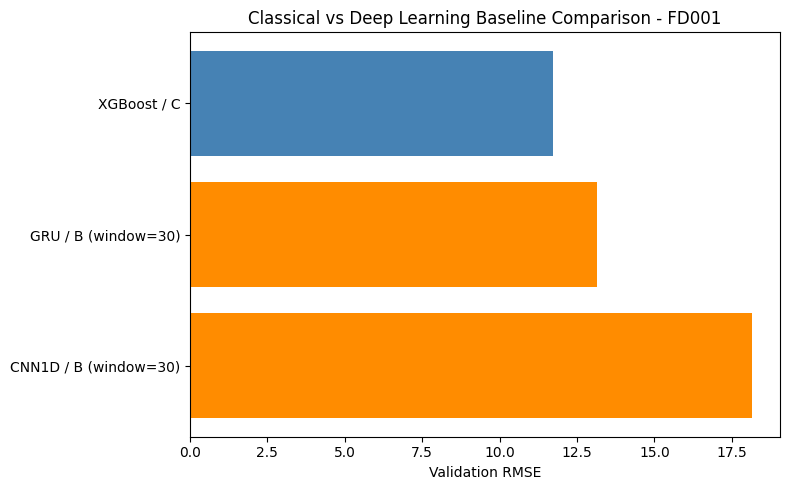

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if t == 'Classical' else 'darkorange' for t in comparison_df['model_type']]
labels = comparison_df['model'] + ' / ' + comparison_df['feature_set']
ax.barh(labels, comparison_df['validation_rmse'], color=colors)
ax.set_xlabel('Validation RMSE')
ax.set_title('Classical vs Deep Learning Baseline Comparison - FD001')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/classical_vs_deep_rmse_comparison_fd001.png', dpi=150)
plt.show()

## 13b. Window-Aligned Classical Baseline Check

The deep learning models are evaluated only on validation rows that have a complete 30-cycle history. With window size 30, the first 29 cycles of each validation engine are excluded from the windowed evaluation. The classical baseline result from Step 4 was computed on the full validation set.

To make the comparison more consistent, the XGBoost predictions are also evaluated on only the same validation rows used by the deep learning models.

In [19]:
# Load XGBoost predictions from Step 4
xgb_pred_path = f'{PRED_DIR}/val_predictions_XGBoost_C_fd001.csv'
xgb_pred_df = pd.read_csv(xgb_pred_path)

# Keep only the same validation rows used in the deep learning windowed evaluation
aligned_classical_df = meta_val[['unit_number', 'time_in_cycles', 'RUL_capped']].merge(
    xgb_pred_df[['unit_number', 'time_in_cycles', 'prediction']],
    on=['unit_number', 'time_in_cycles'],
    how='left'
)

missing_preds = aligned_classical_df['prediction'].isna().sum()
print(f'Total windowed val rows: {len(aligned_classical_df)}')
print(f'Missing aligned classical predictions: {missing_preds}')
aligned_classical_df = aligned_classical_df.dropna(subset=['prediction'])

aligned_rmse = root_mean_squared_error(aligned_classical_df['RUL_capped'], aligned_classical_df['prediction'])
aligned_mae  = mean_absolute_error(aligned_classical_df['RUL_capped'], aligned_classical_df['prediction'])
aligned_r2   = r2_score(aligned_classical_df['RUL_capped'], aligned_classical_df['prediction'])

print(f'Window-aligned XGBoost/C RMSE: {aligned_rmse:.4f}')
print(f'Window-aligned XGBoost/C MAE:  {aligned_mae:.4f}')
print(f'Window-aligned XGBoost/C R2:   {aligned_r2:.4f}')

aligned_comparison_df = pd.DataFrame([
    {
        'model': 'XGBoost',
        'feature_set': 'C',
        'model_type': 'Classical',
        'comparison_basis': 'window-aligned validation rows',
        'validation_rmse': round(aligned_rmse, 4),
        'validation_mae':  round(aligned_mae,  4),
        'validation_r2':   round(aligned_r2,   4),
    },
    {
        'model': 'GRU',
        'feature_set': 'B (window=30)',
        'model_type': 'Deep Learning',
        'comparison_basis': 'windowed validation rows',
        'validation_rmse': float(dl_results_df[dl_results_df['model'] == 'GRU']['validation_rmse'].iloc[0]),
        'validation_mae':  float(dl_results_df[dl_results_df['model'] == 'GRU']['validation_mae'].iloc[0]),
        'validation_r2':   float(dl_results_df[dl_results_df['model'] == 'GRU']['validation_r2'].iloc[0]),
    },
    {
        'model': 'CNN1D',
        'feature_set': 'B (window=30)',
        'model_type': 'Deep Learning',
        'comparison_basis': 'windowed validation rows',
        'validation_rmse': float(dl_results_df[dl_results_df['model'] == 'CNN1D']['validation_rmse'].iloc[0]),
        'validation_mae':  float(dl_results_df[dl_results_df['model'] == 'CNN1D']['validation_mae'].iloc[0]),
        'validation_r2':   float(dl_results_df[dl_results_df['model'] == 'CNN1D']['validation_r2'].iloc[0]),
    }
])

aligned_comparison_df = aligned_comparison_df.sort_values('validation_rmse').reset_index(drop=True)
aligned_comparison_df.to_csv(
    f'{METRICS_DIR}/classical_vs_deep_window_aligned_comparison_fd001.csv',
    index=False
)
print()
print(aligned_comparison_df.to_string(index=False))

Total windowed val rows: 3711
Missing aligned classical predictions: 0
Window-aligned XGBoost/C RMSE: 12.4894
Window-aligned XGBoost/C MAE:  9.2675
Window-aligned XGBoost/C R2:   0.9109

  model   feature_set    model_type               comparison_basis  validation_rmse  validation_mae  validation_r2
XGBoost             C     Classical window-aligned validation rows          12.4894          9.2675         0.9109
    GRU B (window=30) Deep Learning       windowed validation rows          13.1605          9.7182         0.9010
  CNN1D B (window=30) Deep Learning       windowed validation rows          18.1509         14.0382         0.8118


## 14. Actual vs Predicted and Error Distribution (Best Deep Model)

In [20]:
best_dl      = dl_results_df.iloc[0]
best_dl_name = best_dl['model']
best_dl_preds = cnn_preds if best_dl_name == 'CNN1D' else gru_preds

print(f'Best deep learning model: {best_dl_name}')
print(f'  RMSE: {best_dl["validation_rmse"]}')
print(f'  MAE:  {best_dl["validation_mae"]}')
print(f'  R2:   {best_dl["validation_r2"]}')

Best deep learning model: GRU
  RMSE: 13.1605
  MAE:  9.7182
  R2:   0.901


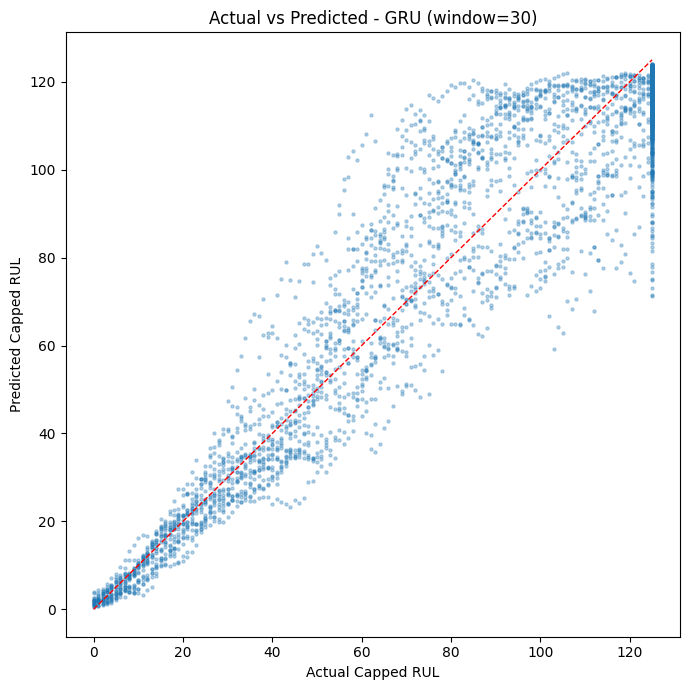

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_val, best_dl_preds, alpha=0.3, s=5)
ax.plot([0, 125], [0, 125], 'r--', linewidth=1)
ax.set_xlabel('Actual Capped RUL')
ax.set_ylabel('Predicted Capped RUL')
ax.set_title(f'Actual vs Predicted - {best_dl_name} (window={WINDOW_SIZE})')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/actual_vs_predicted_best_deep_fd001.png', dpi=150)
plt.show()

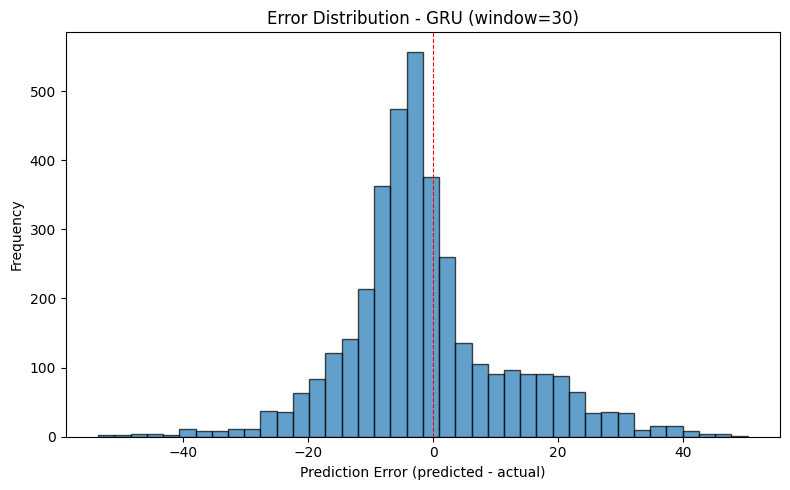

Mean error: -1.33
Std error:  13.09


In [22]:
errors = best_dl_preds - y_val
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7)
ax.set_xlabel('Prediction Error (predicted - actual)')
ax.set_ylabel('Frequency')
ax.set_title(f'Error Distribution - {best_dl_name} (window={WINDOW_SIZE})')
ax.axvline(x=0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_distribution_best_deep_fd001.png', dpi=150)
plt.show()

print(f'Mean error: {errors.mean():.2f}')
print(f'Std error:  {errors.std():.2f}')

## 15. Sample Engine Prediction Trajectories

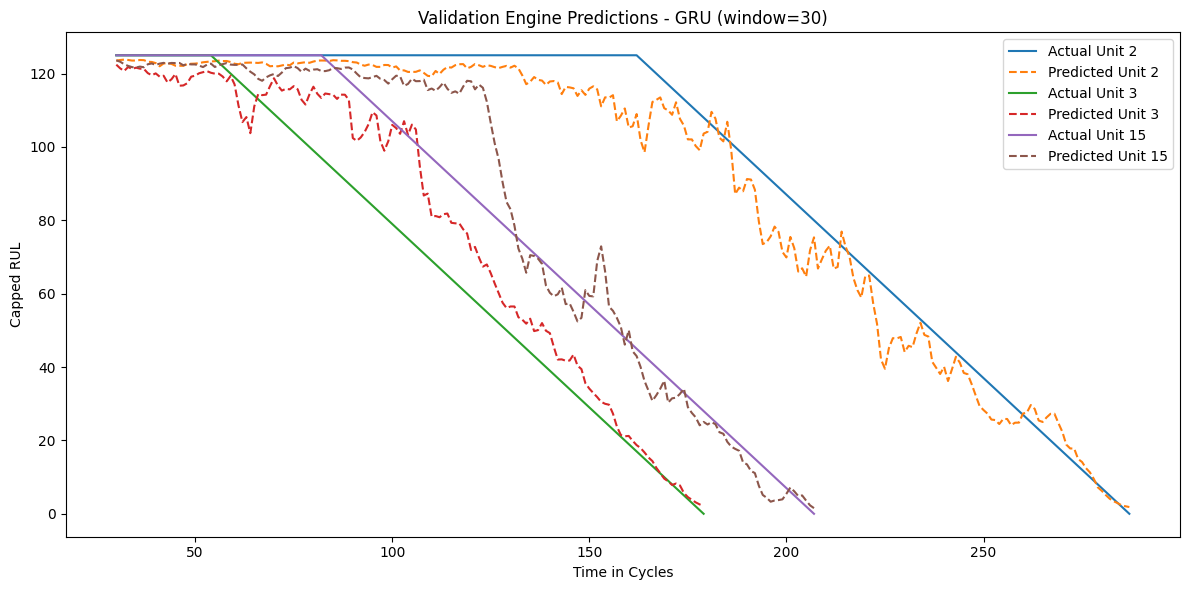

In [23]:
sample_units = meta_val['unit_number'].unique()[:3]
best_pred_df = meta_val.copy()
best_pred_df['prediction'] = best_dl_preds

fig, ax = plt.subplots(figsize=(12, 6))
for unit in sample_units:
    unit_df = best_pred_df[best_pred_df['unit_number'] == unit].sort_values('time_in_cycles')
    ax.plot(unit_df['time_in_cycles'], unit_df['RUL_capped'],
            linewidth=1.5, label=f'Actual Unit {unit}')
    ax.plot(unit_df['time_in_cycles'], unit_df['prediction'],
            linestyle='--', linewidth=1.5, label=f'Predicted Unit {unit}')

ax.set_xlabel('Time in Cycles')
ax.set_ylabel('Capped RUL')
ax.set_title(f'Validation Engine Predictions - {best_dl_name} (window={WINDOW_SIZE})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/sample_engine_prediction_trajectories_deep_fd001.png', dpi=150)
plt.show()

## 16. Window Size Sensitivity Check

A CNN1D-based sensitivity check to observe whether shorter or longer history windows affect validation performance. This is not full hyperparameter optimisation and is not intended to replace the main baseline results.

A CNN1D model was retrained for each window size. Because each run trains a fresh neural network instance, results can vary due to initialisation, early stopping, and GPU execution dynamics. The check is used only to observe broad sensitivity to input history length.

Since the best deep learning model in the main experiment was GRU, further GRU-specific window-size testing may be considered at a later stage.

In [24]:
window_sizes = [15, 30, 50]
sensitivity_results = []

for ws in window_sizes:
    X_tr_w, y_tr_w, _ = create_windows(train_df, feature_cols, target_col, ws)
    X_va_w, y_va_w, _ = create_windows(val_df,   feature_cols, target_col, ws)

    if len(X_tr_w) == 0 or len(X_va_w) == 0:
        print(f'Window size {ws}: skipped (insufficient data)')
        continue

    m = build_cnn_model((ws, len(feature_cols)))
    m.fit(
        X_tr_w, y_tr_w,
        validation_data=(X_va_w, y_va_w),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=0),
            callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
        ],
        verbose=0
    )

    y_p  = np.clip(m.predict(X_va_w, verbose=0).flatten(), 0, 125)
    rmse = root_mean_squared_error(y_va_w, y_p)
    mae  = mean_absolute_error(y_va_w, y_p)
    r2   = r2_score(y_va_w, y_p)

    sensitivity_results.append({
        'window_size':     ws,
        'validation_rmse': round(rmse, 4),
        'validation_mae':  round(mae,  4),
        'validation_r2':   round(r2,   4),
        'train_samples':   len(X_tr_w),
        'val_samples':     len(X_va_w),
    })
    print(f'Window size {ws}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}')

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.to_csv(f'{METRICS_DIR}/window_size_sensitivity_deep_fd001.csv', index=False)
print()
print(sensitivity_df.to_string(index=False))

Window size 15: RMSE=18.2609, MAE=13.7460, R2=0.8087
Window size 30: RMSE=15.8465, MAE=12.0030, R2=0.8565
Window size 50: RMSE=15.6849, MAE=12.1876, R2=0.8578

 window_size  validation_rmse  validation_mae  validation_r2  train_samples  val_samples
          15          18.2609         13.7460         0.8087          15220         4011
          30          15.8465         12.0030         0.8565          14020         3711
          50          15.6849         12.1876         0.8578          12420         3311


## 17. Result Interpretation

The deep learning baselines use time-windowed selected sensor features (Feature Set B) as sequence inputs, while the classical baselines use hand-engineered degradation features (Feature Set C) as tabular inputs. The comparison is therefore not a direct like-for-like test, but rather a comparison of two different input representations for the same prediction task.

If the deep learning baseline did not outperform the strongest classical model, that is understandable at this stage: the classical model benefits from explicitly engineered rolling statistics that encode degradation trends, while the sequence model must learn these patterns implicitly from raw sensor windows.

An additional alignment check was performed in section 13b. The deep learning models are evaluated only on validation rows with a complete 30-cycle window history, which excludes the first 29 cycles of each validation engine (580 rows, 13.5% of the validation set). The window-aligned classical comparison re-evaluates XGBoost on the same subset to ensure a consistent basis for comparison.

## 18. Observations

1. Time-windowed datasets were created using selected sensor features from Feature Set B.
2. Each input sample contains 30 cycles of sensor history and predicts the capped RUL at the final cycle of the window.
3. The train-validation split remains engine-level, consistent with the preprocessing strategy.
4. 1D-CNN and GRU baselines were trained to evaluate whether deep learning models can learn temporal degradation patterns from sensor history.
5. RMSE, MAE and R-squared were used for validation evaluation.
6. The best deep learning baseline is compared with the best classical baseline from Step 4, both on the full validation set and on the window-aligned subset (rows with complete 30-cycle history).
7. The window-aligned comparison excludes the first 29 cycles of each validation engine (580 rows, 13.5% of the validation set) to ensure evaluation is on the same rows for both model types.
8. The result will be used as a reference before developing the multi-view model.

In [25]:
print('Generated artefacts:')
print()
print('Metrics:')
for f in sorted(os.listdir(METRICS_DIR)):
    if 'deep' in f or 'classical_vs' in f or 'window' in f:
        print(f'  {f}')
print()
print('Models:')
for f in sorted(os.listdir(MODEL_DIR)):
    print(f'  {f}')
print()
print('Predictions:')
for f in sorted(os.listdir(PRED_DIR)):
    if 'CNN1D' in f or 'GRU' in f:
        print(f'  {f}')
print()
print('Figures:')
for f in sorted(os.listdir(FIG_DIR)):
    if 'deep' in f or 'training_curve' in f or 'classical_vs_deep' in f:
        print(f'  {f}')

Generated artefacts:

Metrics:
  classical_vs_deep_baseline_comparison_fd001.csv
  classical_vs_deep_window_aligned_comparison_fd001.csv
  deep_learning_baseline_results_fd001.csv
  window_size_sensitivity_deep_fd001.csv

Models:
  CNN1D_B_window30_fd001.keras
  GRU_B_window30_fd001.keras

Predictions:
  val_predictions_CNN1D_B_window30_fd001.csv
  val_predictions_GRU_B_window30_fd001.csv

Figures:
  actual_vs_predicted_best_deep_fd001.png
  classical_vs_deep_rmse_comparison_fd001.png
  error_distribution_best_deep_fd001.png
  sample_engine_prediction_trajectories_deep_fd001.png
  training_curve_CNN1D_fd001.png
  training_curve_GRU_fd001.png
